# Homework 3: Table Manipulation and Visualization

Please complete this notebook by filling in the cells provided. 

**Helpful Resource:**
- [Python Reference](http://data8.org/sp22/python-reference.html): Cheat sheet of helpful array & table methods.

**Recommended Reading**: 
* [Visualization](https://inferentialthinking.com/chapters/07/Visualization.html)

For all problems that you must write explanations and sentences for, you **must** provide your answer in the designated space. **Moreover, throughout this homework and all future ones, please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!



Directly sharing answers is not okay, but discussing problems with other students is encouraged. 

You should start early so that you have time to get help if you're stuck.

In [1]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *
import warnings
warnings.simplefilter('ignore', FutureWarning)

# These lines do some fancy plotting magic.\n",
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## 1. Unemployment

The Great Recession of 2008-2009 was a period of economic decline observed globally, with scale and timing varying from country to country. In the United States, it resulted in a rapid rise in unemployment that affected industries and population groups to different extents.

The Federal Reserve Bank of St. Louis publishes data about jobs in the US.  Below, we've loaded data on unemployment in the United States. There are many ways of defining unemployment, and our dataset includes two notions of the unemployment rate:

1. Among people who are able to work and are looking for a full-time job, the percentage who can't find a job.  This is called the Non-Employment Index, or NEI.
2. Among people who are able to work and are looking for a full-time job, the percentage who can't find any job *or* are only working at a part-time job.  The latter group is called "Part-Time for Economic Reasons", so the acronym for this index is NEI-PTER.  (Economists are great at marketing.)

The source of the data is [here](https://fred.stlouisfed.org/categories/33509).

**Question 1.** The data are in a CSV file called `unemployment.csv`.  Load that file into a table called `unemployment`. 


Type your solution in the following cell. Be sure to include comments explaining your code.

In [2]:
unemployment = Table.read_table('unemployment.csv')


END SOLUTION

**Question 2.** Sort the data in descending order by NEI, naming the sorted table `by_nei`.  Create another table called `by_nei_pter` that's sorted in descending order by NEI-PTER instead. 


Type your solution in the following cell. Be sure to include comments explaining your code.# BEGIN SOLUTION

In [ ]:
by_nei = unemployment.sort('NEI', descending=True)
by_nei_pter = unemployment.sort('NEI-PTER', descending=True)

END SOLUTION

**Question 3.** Use `take` to make a table containing the data for the 11 quarters when NEI was greatest.  Call that table `greatest_nei`.

`greatest_nei` should be sorted in descending order of `NEI`. Note that each row of `unemployment` represents a quarter. 



Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
greatest_nei = unemployment.sort('NEI', descending=True).take(np.arange(11))

END SOLUTION

**Question 4.** It's believed that many people became PTER (recall: "Part-Time for Economic Reasons") in the "Great Recession" of 2008-2009.  NEI-PTER is the percentage of people who are unemployed (included in the NEI) plus the percentage of people who are PTER.

Compute an array containing the percentage of people who were PTER in each quarter.  (The first element of the array should correspond to the first row of `unemployment`, and so on.) 

*Note:* Use the original `unemployment` table for this.


In [ ]:
nei_percent = unemployment.column('NEI')
pter_percent = unemployment.column('NEI-PTER')
nei_pter = nei_percent + pter_percent

END SOLUTION

**Question 5.** Add `pter` as a column to `unemployment` (name the column `PTER`) and sort the resulting table by that column in descending order.  Call the resulting table `by_pter`.

Try to do this with a single line of code, if you can.


In [ ]:
by_pter = unemployment.with_column('PTER', unemployment.column('NEI') + unemployment.column('NEI-PTER')).sort('PTER', descending=True)

END SOLUTION

**Question 6.** Create a line plot of PTER over time. To do this, create a new table called `pter_over_time` by making a copy of the `unemployment` table and adding two new columns: `Year` and `PTER` using the `year` array and the `pter` array, respectively. Then, generate a line plot using one of the table methods you've learned in class.

The order of the columns matter for our correctness tests, so be sure `Year` comes before `PTER`. 

*Note:* When constructing `pter_over_time`, do not just add the `year` column to the `by_pter` table. Please follow the directions in the question above.


Type your solution in the following cell. Be sure to include comments explaining your code.

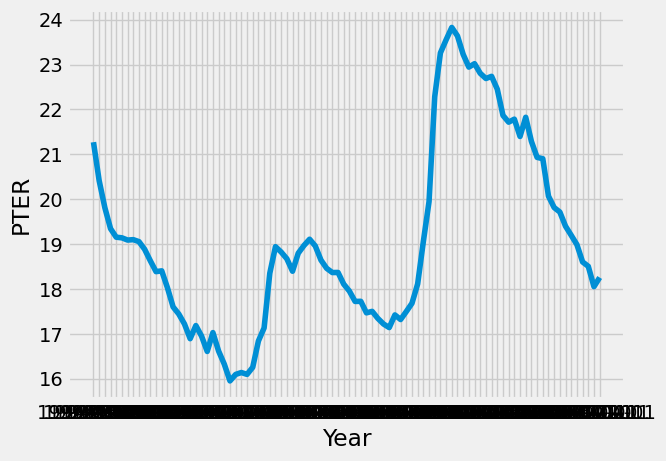

In [3]:
import matplotlib.pyplot as plt
year = unemployment.column('Date') 

pter_over_time = unemployment.with_columns(
    'Year', year,  
    'PTER', unemployment.column('NEI-PTER') + unemployment.column('NEI')  
)

plt.plot(pter_over_time.column('Year'), pter_over_time.column('PTER'))
plt.xlabel('Year')
plt.ylabel('PTER')
plt.xticks(ticks=pter_over_time.column('Year'))
plt.show()

END SOLUTION

**Question 7.** Were PTER rates high during the Great Recession (that is to say, were PTER rates particularly high in the years 2008 through 2011)? Assign `highPTER` to `True` if you think PTER rates were high in this period, or `False` if you think they weren't. 


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
highPTER = True

END SOLUTION

## 2. Birth Rates

The following table gives Census-based population estimates for each US state on both July 1, 2015 and July 1, 2016. The last four columns describe the components of the estimated change in population during this time interval. **For all questions below, assume that the word "states" refers to all 52 rows including Puerto Rico and the District of Columbia.**

The data was taken from [here](http://www2.census.gov/programs-surveys/popest/datasets/2010-2016/national/totals/nst-est2016-alldata.csv). (Note: If it doesn't download for you when you click the link, please copy and paste it into your address bar!) If you want to read more about the different column descriptions, click [here](http://www2.census.gov/programs-surveys/popest/datasets/2010-2015/national/totals/nst-est2015-alldata.pdf).

The raw data is a bit messy—run the cell below to clean the table and make it easier to work with.

In [ ]:
# Don't change this cell; just run it.
pop = Table.read_table("nst-est2016-alldata.csv").where('SUMLEV', 40).select([1, 4, 12, 13, 27, 34, 62, 69])
pop = pop.relabeled('POPESTIMATE2015', '2015').relabeled('POPESTIMATE2016', '2016')
pop = pop.relabeled('BIRTHS2016', 'BIRTHS').relabeled('DEATHS2016', 'DEATHS')
pop = pop.relabeled('NETMIG2016', 'MIGRATION').relabeled('RESIDUAL2016', 'OTHER')
pop = pop.with_columns("REGION", np.array([int(region) if region != "X" else 0 for region in pop.column("REGION")]))
pop.set_format([2, 3, 4, 5, 6, 7], NumberFormatter(decimals=0)).show(5)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/camel/Downloads/nst-est2016-alldata.csv'

**Question 1.** Assign `us_birth_rate` to the total US annual birth rate during this time interval. The annual birth rate for a year-long period is the total number of births in that period as a proportion of the total population size at the start of the time period.

*Hint:* Which year corresponds to the start of the time period?


Type your solution in the following cell. Be sure to include comments explaining your code.

In [6]:
import math
us_birth_rate = (sum(pop.column('BIRTHS')))/(sum(pop.column('2015')))

NameError: name 'pop' is not defined

END SOLUTION

**Question 2.** Assign `movers` to the number of states for which the **absolute value** of the **annual rate of migration** was higher than 1%. The annual rate of migration for a year-long period is the net number of migrations (in and out) as a proportion of the population size at the start of the period. The `MIGRATION` column contains estimated annual net migration counts by state. 

*Hint*: `migration_rates` should be a table and `movers` should be a number.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
migration_rates = pop.with_column('Migration Rate', abs(pop.column('MIGRATION')/pop.column('2015'))) 
movers = migration_rates.where('Migration Rate', are.above(0.01)).num_rows

END SOLUTION

**Question 3.** Assign `west_births` to the total number of births that occurred in region 4 (the Western US). 

*Hint:* Make sure you double check the type of the values in the `REGION` column and appropriately filter (i.e. the types must match!).


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
west_births = sum(pop.where('REGION', are.equal_to(4)).column('BIRTHS'))

END SOLUTION

**Question 4.** In the next question, you will be creating a visualization to understand the relationship between birth and death rates. The annual death rate for a year-long period is the total number of deaths in that period as a proportion of the population size at the start of the time period.

What visualization is most appropriate to see if there is an association between birth and death rates during a given time interval?

1. Line Graph
2. Bar Chart
3. Scatter Plot

Assign `visualization` below to the number corresponding to the correct visualization. 

Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
visualization = 3

END SOLUTION

**Question 5.** In the code cell below, create a visualization that will help us determine if there is an association between birth rate and death rate during this time interval. It may be helpful to create an intermediate table here. 

Things to consider:

- What type of chart will help us illustrate an association between 2 variables?
- How can you manipulate a certain table to help generate your chart?
- Check out the Recommended Reading for this homework!


Type your solution in the following cell. Be sure to include comments explaining your code.

In [7]:
birth_rates = pop.column('BIRTHS') / pop.column('2015')
death_rates = pop.column('DEATHS') / pop.column('2015')
birth_death = Table().with_columns("Birth Rates", birth_rates, "Death Rates", death_rates)
birth_death.scatter("Birth Rates", "Death Rates")
plt.show()

NameError: name 'pop' is not defined

END SOLUTION

**Question 6.** True or False: There is an association between birth rate and death rate during this time interval. 

Assign `assoc` to `True` or `False` in the cell below. 


Type your solution in the following cell. Be sure to include comments explaining your code.

END SOLUTION

## 3. Uber

Below we load tables containing 200,000 weekday Uber rides in the Manila, Philippines, and Boston, Massachusetts metropolitan areas from the [Uber Movement](https://movement.uber.com) project. The `sourceid` and `dstid` columns contain codes corresponding to start and end locations of each ride. The `hod` column contains codes corresponding to the hour of the day the ride took place. The `ride time` column contains the length of the ride in minutes.

In [8]:
boston = Table.read_table("boston.csv")
manila = Table.read_table("manila.csv")
print("Boston Table")
boston.show(4)
print("Manila Table")
manila.show(4)

Boston Table


sourceid,dstid,hod,ride time
584,33,7,11.866
1013,1116,13,17.7993
884,1190,22,19.3488
211,364,1,1.7235


Manila Table


sourceid,dstid,hod,ride time
544,5,22,22.8115
302,240,21,7.02267
278,99,16,21.6437
720,775,18,13.0597


**Question 1.** Produce a histogram that visualizes the distributions of all ride times in Boston using the given bins in `equal_bins`. 

Type your solution in the following cell. Be sure to include comments explaining your code.

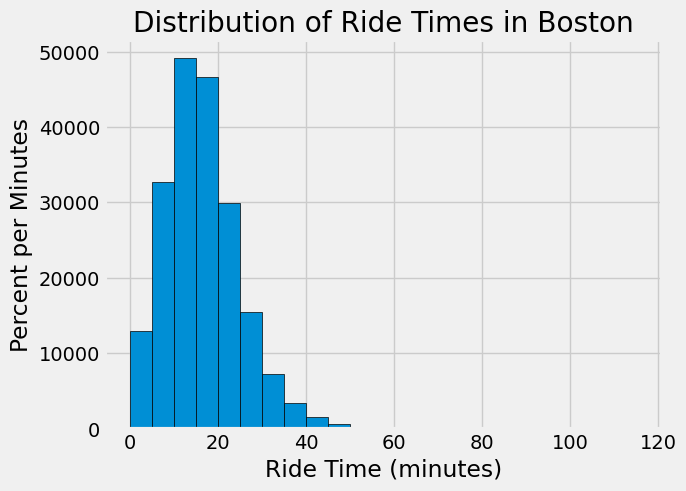

In [9]:
equal_bins = np.arange(0, 120, 5)

#Your comments and solution
ride_times = boston.column('ride time') 
plt.hist(ride_times, bins=equal_bins, edgecolor='black') 
plt.xlabel('Ride Time (minutes)')
plt.ylabel('Percent per Minutes')
plt.title('Distribution of Ride Times in Boston')
plt.show()

END SOLUTION

**Question 2.** Now, produce a histogram that visualizes the distribution of all ride times in Manila using the given bins.

Type your solution in the following cell. Be sure to include comments explaining your code.

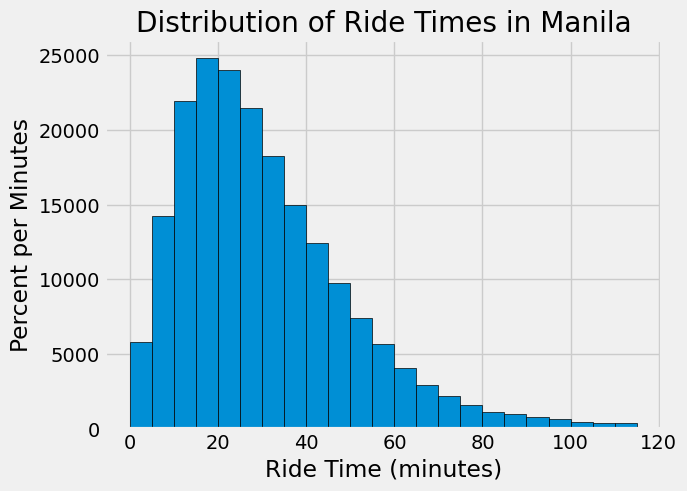

In [10]:
equal_bins = np.arange(0, 120, 5)
ride_times2 = manila.column('ride time')
plt.hist(ride_times2, bins=equal_bins, edgecolor='black')
plt.xlabel('Ride Time (minutes)')
plt.ylabel('Percent per Minutes')
plt.title('Distribution of Ride Times in Manila')
plt.show()

END SOLUTION

**Question 3.** Let's take a closer look at the y-axis label. Assign `unit_meaning` to an integer (1, 2, 3) that corresponds to the "unit" in "Percent per unit".

1. minute  
2. ride time  
3. second


Type your solution in the following cell. Be sure to include comments explaining your code.

In [11]:
#Your comments and solution


unit_meaning = 1

END SOLUTION

**Question 4.** Assign `boston_under_15` and `manila_under_15` to the percentage of rides that are less than 15 minutes in their respective metropolitan areas. Use the height variables provided below in order to compute the percentages. Your solution should only use height variables, numbers, and mathematical operations. You should **not** access the tables `boston` and `manila` in any way.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [12]:
boston_under_5_height = 1.2
boston_5_to_under_10_height = 3.2
boston_10_to_under_15_height = 4.9

manila_under_5_height = 0.6
manila_5_to_under_10_height = 1.4
manila_10_to_under_15_height = 2.2

#Your comments and solution

boston_under_15 = boston_10_to_under_15_height = 4.9
manila_under_15 = manila_10_to_under_15_height = 2.2
boston_under_15, manila_under_15

(4.9, 2.2)

END SOLUTION

**Question 5.** Let's take a closer look at the distribution of ride times in Boston. Assign `boston_median_bin` to an integer (1, 2, 3, or 4) that corresponds to the bin that contains the median time. 

1. 0-8 minutes  
2. 8-14 minutes  
3. 14-20 minutes  
4. 20-40 minutes  

*Hint:* The median of a sorted list has half of the list elements to its left, and half to its right.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
#Your comments and solution


boston_median_bin = 4

END SOLUTION

**Question 6.** Identify one difference between the histograms, in terms of the statistical properties. Can you comment on the average and/or skew of each histogram?

*Hint*: The best way to do this is to compare the two histograms (from 3.1 and 3.2) visually.


Type your solution in the following cell. Be sure to include comments explaining your code.

END SOLUTION

**Question 7.** Why is your solution in Question 6 the case? Based on one of the following two readings, why are the distributions for Boston and Manila different? 

- [Boston reading](https://www.climatestotravel.com/climate/united-states/boston)
- [Manila reading](https://manilafyi.com/why-is-manila-traffic-so-bad/)

*Hint:* Try thinking about external factors of the two cities that may be causing the difference! There may be multiple different factors that come into play.


Type your solution in the following cell. Be sure to include comments explaining your code.

END SOLUTION

## 4. Histograms

Consider the following scatter plot: 

![](scatter.png)

The axes of the plot represent values of two variables: $x$ and $y$. 

Suppose we have a table called `t` that has two columns in it:

- `x`: a column containing the x-values of the points in the scatter plot
- `y`: a column containing the y-values of the points in the scatter plot

Below, you are given three histograms—one corresponds to column `x`, one corresponds to column `y`, and one does not correspond to either column. 

**Histogram A:**

![](var3.png)

**Histogram B:**

![](var1.png)

**Histogram C:**

![](var2.png)

**Question 1.** Suppose we run `t.hist('x')`. Which histogram does this code produce? Assign `histogram_column_x` to either 1, 2, or 3. 

1. Histogram A
2. Histogram B
3. Histogram C


In [ ]:
histogram_column_x = 1

END SOLUTION

**Question 2.** State at least one reason why you chose the histogram from Question 1. **Make sure to clearly indicate which histogram you selected** (ex: "I chose histogram A because ..."). 


Type your solution in the following cell. Be sure to include comments explaining your code.

END SOLUTION

**Question 3.** Suppose we run `t.hist('y')`. Which histogram does this code produce? Assign `histogram_column_y` to either 1, 2, or 3. 

1. Histogram A
2. Histogram B
3. Histogram C


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
histogram_column_y = 2

END SOLUTION

**Question 4.** State at least one reason why you chose the histogram from Question 3.  **Make sure to clearly indicate which histogram you selected** (ex: "I chose histogram A because ..."). 


Type your solution in the following cell. Be sure to include comments explaining your code.

END SOLUTION

You're done with Homework 3!  
